# CS2006: Advanced Programming Projects

## Practical P2: Data analysis and visualisation Python

# Project Introduction

This project required a group of three to analyze and visually present data on a provided census in Python using libraries like **pandas** and **matplotlib**.  
The program should check for data inconsistencies and present the data in a way that can easily be interpreted.

## Team Collaboration

For this project, we collaborated effectively as a team and managed to maintain our own programming style throughout the assignment.

## Implementation

We successfully implemented all of the following tasks:

- **Basic**
- **Easy**
- **Medium**
- **Medium to Hard**
- **First Hard**: Displaying data using a map

## Testing

We created an *invalidCensus.csv* file to test our cleanup process. When you change the file path in the cleanup.py file, you can see that it finds and removes any errors in the data, as well as pointing out some illogical data.

## Problem Encountered

When we convert the notebook to an HTML file, the widgets are displayed, but they no longer function as there is no python backing it, so the plots are best viewed in notebook form.

One problem we encountered was trying to implement a script to convert our Python notebook to a PDF, which required downloading **LaTeX** with `sudo`, something we cannot do.  
Instead, we used the following website to convert it:

[html2pdf.com](https://html2pdf.com/)


### Loading the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns
from ipywidgets import interact, interactive_output, VBox, fixed
import numpy as np
import geopandas
import sys
sys.path.insert(0, '../code')
import labels

In [2]:
%run "../code/cleanup.py"
df = pd.read_csv("../data/cleaned_data.csv")

=== Data Quality Check Results ===

Lenght of orignal dataset: 604351
Length of cleaned dataset: 604351

1. Missing Values:
resident_id_m                   0
approx_social_grade             0
country_of_birth_3a             0
economic_activity_status_10m    0
ethnic_group_tb_6a              0
health_in_general               0
hh_families_type_6a             0
hours_per_week_worked           0
in_full_time_education          0
industry_10a                    0
iol22cd                         0
legal_partnership_status_6a     0
occupation_10a                  0
region                          0
religion_tb                     0
residence_type                  0
resident_age_7d                 0
sex                             0
usual_short_student             0
dtype: int64

2. Duplicate Rows:
Number of duplicate rows: 0

3. Data Types:
resident_id_m                   object
approx_social_grade              int64
country_of_birth_3a              int64
economic_activity_status_10m     int

## Draw bar charts

### Define dropdown box

In [3]:
selection = widgets.Dropdown(
    options = [
        ("Social Grade",      "approx_social_grade"),
        ("Country of Birth",  "country_of_birth_3a"),
        ("Economic Activity", "economic_activity_status_10m"),
        ("Ethnic Group",      "ethnic_group_tb_6a"),
        ("Health",            "health_in_general"),
        ("Family",            "hh_families_type_6a"),
        ("Hours Worked",      "hours_per_week_worked"),
        ("Education",         "in_full_time_education"),
        ("London",            "iol22cd"),
        ("Partner",           "legal_partnership_status_6a"),
        ("Region",            "region"),
        ("Occupation",        "occupation_10a"),
        ("Religion",          "religion_tb"),
        ("Residence",         "residence_type"),
        ("Age",               "resident_age_7d"),
        ("Sex",               "sex"),
        ("Usual Student",     "usual_short_student"),
        ("Hours worked",      "hours_per_week_worked"),
        ("Industry",          "industry_10a"),
    ],
    value = "hours_per_week_worked",
    description = "Chart to display: ",
    style = {'description_width': 'initial'}
)

This dropdown box is used throughout the solution, mapping the easily readable variables to the names they're stored as in the csv file. Throughout the notebook, we also use a file that we created called *labels.py* that allows for transformations of numbers from the data set to what they actually represent.

### Initialise bar chart functions

In [4]:
def draw_bar_chart(column):
    df2 = df.copy()

    # Load labes from the labels module
    label = labels.label_map[column]
    title = labels.name_map[column] + " Distributions"
    xlabel = labels.name_map[column]

    # Count the number of records for the selected column
    counts = df2.groupby(column)[column].count()
    # Map the correct labels to the x axis variables
    counts.index = counts.index.map(label)
    counts.plot(kind='bar')

    # Set the title and labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Residents")

By making the draw bar chart implimentation into a function it can take input from a dropdown widget, allowing it to display any record in the table.     

### Bar charts for basic requirements

In [5]:
# Display the bar chart
out = interactive_output(draw_bar_chart, {'column': selection})
display(VBox([selection, out]))

To show the bar chart for age or occupation distribution as required in the basic requirements select either `Age` or `Occupation` from the dropdown box.   
The age distrobution shows us that for all sections other than under 15s and 65s and over there is around 70,000 records. It makes sense that the other two have more records since their age range is greater that the limited 10 year sections of the other 5.  

# Easy requirements

### Initialise pie chart functions

In [6]:
def draw_pie_chart(column):
    df2 = df.copy()

    # Load labels from the labels module
    label = labels.label_map[column]
    title = labels.name_map[column] + " Distributions"

    # Count the number of records for the selected column
    counts = df2.groupby(column)[column].count()
    # Map the correct labels to the variables
    counts.index = counts.index.map(label)
    counts.plot(kind='pie', autopct='%1.1f%%')

    # Set the title and labels
    plt.title(title)
    plt.ylabel("")

The same principal for the bar charts was applied to pie charts, allowing them to display any catagory again.

### Pie Charts drawn

In [7]:
# Display the pie chart
out = interactive_output(draw_pie_chart, {'column': selection})
display(VBox([selection, out]))

The easy requirements ask for pie charts for health descriptors and for ethnic groups, to see these select `Health` or `Ethnic Group` from the dropdown box.    
By using the health section we can see that the majority of the records are in good health, with 48% in "Very good health" and 33% in "Good health", only 1.2% of the section have "Very bad health"

# MEDIUM REQUIRMENTS 


## Group By tables for Hours Worked Vs Industry and Occupation Vs Social Grade

### 1. Number of records by hours by week and industry

In [8]:
def draw_table(variable1, variable2):
    df2 = df.copy()

    # Only draw the table if the two variables are different
    if variable1 == variable2:
        print("Please select two different variables.")
        return
      
    # Load labels and display order from the labels module
    label1 = labels.label_map[variable1]
    label2 = labels.label_map[variable2]
    order1 = labels.order_map[variable1]
    order2 = labels.order_map[variable2]

    # Map the correct labels to the variables
    df2[variable1] = df2[variable1].map(label1)
    df2[variable2] = df2[variable2].map(label2)

    # Set the order of the categories
    df2[variable1] = pd.Categorical(df2[variable1], categories=order1, ordered=True)
    df2[variable2] = pd.Categorical(df2[variable2], categories=order2, ordered=True)

    # Create a crosstab table
    table = pd.crosstab(
        df2[variable1],
        df2[variable2],
        margins=True,
        margins_name="Total"
    )

    # Set the index and column names
    table.index.name = labels.name_map[variable1]
    table.columns.name = labels.name_map[variable2]
    
    display(table)

Again the tables are designed to accept any two catagories and display them accuratly. The code for this section is more complicated however, due to the need to sort the table orders and label the variables for two different sections.

In [9]:
# Define two new dropdowns for the table selection, using the same options
table_selection1 = widgets.Dropdown(
    options = selection.options,
    value = "hours_per_week_worked",
    description = "Table to display: ",
    style = {'description_width': 'initial'}
)
table_selection2 = widgets.Dropdown(
    options = selection.options,
    value = "industry_10a",
    description = "Table to display: ",
    style = {'description_width': 'initial'}
)


# Display the table
out = interactive_output(draw_table, {
    'variable1':        table_selection1,
    'variable2':        table_selection2
})

display(VBox([table_selection1, table_selection2, out]))

The two required tables for this section are mapping hours worked per week against industry and occupation against approximate social grade, again selectable by using the dropdown widget.   
Analysis of the first and we can see that there is 171,000 records in "does not apply for" both records, presumably people who don't work. More interestingly are the 150,000 people who work in an industry both chose "Does not apply", these people could potentially be working very variable hours per week or currently be on leave.   
When looking at the occupation against approximate social grade table we can see the expected results that the higher social grade records typically work in professional occupations or as managers and directors while the lower social grades are far more likely to work in Elementary Occupations 

### 2. Number of records by occupation and approximate social grade

### Extra addition to the above - Heatmaps for both tables

#### Heatmap for Hours Worked vs Industry

In [10]:
def draw_heatmap(variable1, variable2, colour):
    df2 = df.copy()

    # Only draw the heatmap if the two variables are different
    if variable1 == variable2:
        print("Please select two different variables.")
        return  
    
    # Load labels and display order from the labels module
    label1 = labels.label_map[variable1]
    label2 = labels.label_map[variable2]
    order1 = labels.order_map[variable1]
    order2 = labels.order_map[variable2]

    # Map the correct labels to the variables
    df2[variable1] = df2[variable1].map(label1)
    df2[variable2] = df2[variable2].map(label2)

    # Set the order of the categories
    df2[variable1] = pd.Categorical(df2[variable1], categories=order1, ordered=True)
    df2[variable2] = pd.Categorical(df2[variable2], categories=order2, ordered=True)


    # Create a heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        pd.crosstab(df2[variable1], df2[variable2]),
        annot=True, fmt='d', cmap=colour, cbar=False
    )

    # Set the title and labels
    plt.title(labels.name_map[variable1] + " vs " + labels.name_map[variable2])
    plt.ylabel(labels.name_map[variable1])
    plt.xlabel(labels.name_map[variable2])

The Heatmap function looks nearly identical to the previous table function, with very similar labelling and drawing. The key change is the use of the sns heatmap function rather than the pandas crosstab 

In [11]:
# Define a widget for the colour selection
colour_selection = widgets.Dropdown(
    options = ["Blues", "Greens", "Reds", "Purples", "Oranges"],
    description = "Colour scheme: ",
    style = {'description_width': 'initial'}
)


# Display the heatmap
out = interactive_output(draw_heatmap, {
    'variable1':        table_selection1,
    'variable2':        table_selection2,
    'colour':           colour_selection
})

display(VBox([table_selection1, table_selection2, colour_selection, out]))

By drawing the same required tables from above in a heatmap the patterns previously noted are even more easy to see.

## Medium Requirments 2
## Ecomomic Activitiy Analysis

In [12]:
def draw_economic_bar_chart(column):
    df2 = df.copy()

    # Ensure the selected column is not "economic_activity_status_10m"
    if column == "economic_activity_status_10m":
        print("Please select a different variable.")
        return

    # Load labels from the labels module
    label = labels.label_map[column]
    xlabel = labels.name_map[column]

    # Create a new dataframe with only the relevant records
    economic_active = df2[df2['economic_activity_status_10m'].isin([1, 2, 3, 4])]  # Active status codes 1,2,3,4
    economic_inactive = df2[df2['economic_activity_status_10m'].isin([5, 6, 7, 8, 9])]  # Inactive status codes 5, 6, 7, 8,9

    # Count the number of records for the selected column
    active_by_variable = economic_active.groupby(column)[column].count()
    inactive_by_variable = economic_inactive.groupby(column)[column].count()

    # Map the correct labels to the x axis variables
    active_by_variable.index = active_by_variable.index.map(label)
    inactive_by_variable.index = inactive_by_variable.index.map(label)


    x = np.arange(len(active_by_variable.index)) 
    w = 0.4

    # Create a bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(2*x + w/2, active_by_variable.values, w,  label='Active', alpha=0.7)
    ax.bar(2*x - w/2, inactive_by_variable.values, w, label='Inactive', alpha=0.7)
    plt.title('Economically Active vs Inactive People by ' + xlabel)
    plt.xticks(2*x, active_by_variable.index, rotation=90)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.show()

The same repeatable principle was used on the comparison bar chart function. This time with the caviet that two bar plots are being drawn onto the same graph and that a new dataframe has to be created for both economically active and inactive, using the economic activity status. 

In [13]:
# Display the bar chart
out = interactive_output(draw_economic_bar_chart, {
    'column': selection
})

display(VBox([selection, out]))

Using this chart you can compare the number of economically active and inactive people based on both age and health groups.   
When analyising the age charts as expected the least active group is the 65 and over group, due to the large sections of this group which will be retired. The youngest age group also has a significant inactive section, this time due to the student population.    
Interestingly it's clear that the sum of both active and inactive people for the oldest group is more than that of any other group, this is due to both the larger age range of this group as well as the removal of "Does not apply" having the smallest effect on this section.    


Comparing health with econmic activity again produces a very expected value, with the majority of people in good and very good health economically active, while people in bad or very bad health are far less likely to be active.   

In [14]:
def draw_student_economic_bar_chart(column):
    df2 = df.copy()

    if column == "economic_activity_status_10m":
        print("Please select a different variable.")
        return
    
    # Load labels from the labels module
    label = labels.label_map[column]
    xlabel = labels.name_map[column]

    # Create a new dataframe with only the relevant records
    student = df2[df2['economic_activity_status_10m'].isin([4, 6])]  
    not_student = df2[df2['economic_activity_status_10m'].isin([1, 2, 3, 5, 7, 8, 9])]  

    # Count the number of records for the selected column
    student_for_variable = student.groupby(column)[column].count()
    not_student_for_variable = not_student.groupby(column)[column].count()

    # Map the correct labels to the x axis variables
    student_for_variable.index = student_for_variable.index.map(label)
    not_student_for_variable.index = not_student_for_variable.index.map(label)


    x = np.arange(len(student_for_variable.index)) 
    w = 0.4

    # Create a bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(2*x + w/2, student_for_variable.values, w,  label='Students')
    ax.bar(2*x - w/2, not_student_for_variable.values, w, label='Non-Students')
    plt.title(xlabel + ' for Students vs Non-Students')
    plt.xticks(2*x, student_for_variable.index, rotation=90)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.show()

In [15]:
# Display the bar chart
out = interactive_output(draw_student_economic_bar_chart, {
    'column': selection
})

display(VBox([selection, out]))

# Hard Requirement

## Map of the Uk

Our first goal is to create a map of the UK that shows the amount of records that come from each region
First we must import the shapefile that will give us the geographic data. We are using the geopandas library

In [16]:
df = pd.read_csv("../data/publicmicrodatateachingsample.csv")
map = geopandas.read_file("../data/shapeFileData/NUTS1_Jan_2018_UGCB_in_the_UK.shp")
map.head()

,nuts118cd,nuts118nm,bng_e,bng_n,long,lat,GlobalID,geometry
0,UKC,North East (England),417313,600358,-1.72890,55.297031,628608f5-673c-45c8-9082-f57ed9604a20,"MULTIPOLYGON (((397942.931 657535.008, 400000 ..."
1,UKD,North West (England),350015,506280,-2.77237,54.449451,0413c215-94f7-4f2e-a0fd-37d517177413,"MULTIPOLYGON (((357136.203 587050.898, 356937...."
2,UKE,Yorkshire and The Humber,446903,448736,-1.28712,53.932640,d608863c-86bd-4877-b3b8-247794a0825a,"POLYGON ((479999.978 517670.16, 481340.496 515..."
3,UKF,East Midlands (England),477660,322635,-0.84967,52.795719,428c9691-f97b-4fa3-aef8-b3d8c0789cf9,"POLYGON ((516022.702 412210.895, 515854.099 41..."
4,UKG,West Midlands (England),386294,295477,-2.20358,52.556969,a8a5953c-6a23-4fca-b1c7-96d80a29dd95,"POLYGON ((409402.997 365710.796, 412633.099 36..."


However, we can see that rather than using the region codes that the census data uses, this data set uses *nuts118cd* as the region identifier. To fix this, we will map these to the region codes that our data set uses. We will also rename the column name to *region* to make it more user readable.

In [17]:
# Rename the region codes to the modern version that the census data uses
map["nuts118cd"] = map["nuts118cd"].map({"UKC": "E12000001", "UKD": "E12000002", "UKE": "E12000003", "UKF": "E12000004", "UKG": "E12000005", "UKH": "E12000006", "UKI": "E12000007", "UKJ": "E12000008", "UKK": "E12000009", "UKL": "W92000004", "UKM": "S99999999" ,"UKN": "N99999999"})
map.rename(columns={"nuts118cd": "region"}, inplace=True)
map

,region,nuts118nm,bng_e,bng_n,long,lat,GlobalID,geometry
0,E12000001,North East (England),417313,600358,-1.728900,55.297031,628608f5-673c-45c8-9082-f57ed9604a20,"MULTIPOLYGON (((397942.931 657535.008, 400000 ..."
1,E12000002,North West (England),350015,506280,-2.772370,54.449451,0413c215-94f7-4f2e-a0fd-37d517177413,"MULTIPOLYGON (((357136.203 587050.898, 356937...."
2,E12000003,Yorkshire and The Humber,446903,448736,-1.287120,53.932640,d608863c-86bd-4877-b3b8-247794a0825a,"POLYGON ((479999.978 517670.16, 481340.496 515..."
3,E12000004,East Midlands (England),477660,322635,-0.849670,52.795719,428c9691-f97b-4fa3-aef8-b3d8c0789cf9,"POLYGON ((516022.702 412210.895, 515854.099 41..."
4,E12000005,West Midlands (England),386294,295477,-2.203580,52.556969,a8a5953c-6a23-4fca-b1c7-96d80a29dd95,"POLYGON ((409402.997 365710.796, 412633.099 36..."
5,E12000006,East of England,571074,263229,0.504146,52.240669,5b0cd82b-5790-499e-92b3-b8f1ab8c601c,"MULTIPOLYGON (((599964.098 346659.983, 608692...."
6,E12000007,London,517516,178392,-0.308640,51.492271,2ae606b7-b7dc-4d57-a422-84064399cbba,"POLYGON ((537543.796 199883.103, 537625.1 1960..."
7,E12000008,South East (England),470062,172924,-0.993110,51.450970,53710b5b-1dfe-4a52-bfb9-a07005f418be,"MULTIPOLYGON (((493941.101 254585.705, 493776...."
8,E12000009,South West (England),285015,102567,-3.633430,50.811192,da810a21-072d-49d1-853e-48b75dd73c53,"MULTIPOLYGON (((416007.596 246053.797, 417496...."
9,W92000004,Wales,263406,242881,-3.994160,52.067410,ec38afc1-b206-49a1-bfaf-48c9836e2d02,"MULTIPOLYGON (((314837.003 381391.297, 315637...."


Now we need to grab the counts for each region from our original data set. By adding this our **map** DataFrame, we can then use this data when we plot the map

In [18]:
# Get the counts and add this to the geographic DataFrame
region_counts = df.groupby("region")["region"].count()
map = map.join(region_counts.rename("record_counts"), on="region")

#We can see that they were added
map[["region", "record_counts"]]

,region,record_counts
0,E12000001,26767.0
1,E12000002,75080.0
2,E12000003,55469.0
3,E12000004,49440.0
4,E12000005,60231.0
5,E12000006,64258.0
6,E12000007,89489.0
7,E12000008,94344.0
8,E12000009,57815.0
9,W92000004,31458.0


Now that we have the data we want combined with the geographic data, we can plot it

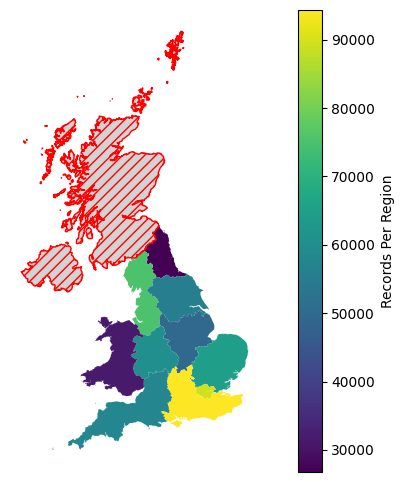

In [19]:
ax = map.plot(
    figsize=(10,6), 
    column="record_counts", 
    legend=True,
    legend_kwds={"label": "Records Per Region", "orientation": "vertical"},
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    },
    )

ax.set_axis_off()

Through this map, we can see that most of the data comes from the Southeast, which makes sense considering it has the highest population density.

We can use a similar idea to find the most responses for any of the statistics by region

*Note: To change which stat you are looking at, change the occupation string and corresponding map to whichever column you'd like to observe*

In [20]:
# Make a table of occupation per region
df['stat'] = df['occupation_10a'].map(labels.occupation_labels)
table = pd.crosstab(df["region"], df["stat"])
# Get rid of does not apply so we get interesting results
table = table.drop(columns=["Does not apply"])
table

stat,Administrative and secretarial occupations,Associate professional and technical occupations,"Caring, leisure and other service occupations",Elementary occupations,"Managers, directors and senior officials","Process, plant and machine operatives",Professional occupations,Sales and customer service occupations,Skilled trades occupations
region,,,,,,,,,
E12000001,2001,2034,1901,2639,1522,1637,3011,2088,1984
E12000002,5628,5737,5337,7270,5208,4293,9064,5073,5290
E12000003,3947,4132,3822,5709,3902,3382,6269,3764,4221
E12000004,3690,3721,3448,5384,3719,3363,5739,3291,3654
E12000005,4479,4349,4057,6067,4232,3776,6797,3763,4523
E12000006,5391,5423,4440,5567,5656,3400,8299,3945,4904
E12000007,6134,8649,5138,6854,7942,3215,14080,4883,4674
E12000008,8055,8900,6335,7372,9137,3919,13279,5644,6470
E12000009,4964,4942,4378,5111,5170,2855,7606,3864,4973


In [21]:
#Add the maximum occupation for each region as a new column
max_stats = table.idxmax(axis=1)
map = map.join(max_stats.rename("max_stat"), on="region")
map

,region,nuts118nm,bng_e,bng_n,long,lat,GlobalID,geometry,record_counts,max_stat
0,E12000001,North East (England),417313,600358,-1.728900,55.297031,628608f5-673c-45c8-9082-f57ed9604a20,"MULTIPOLYGON (((397942.931 657535.008, 400000 ...",26767.0,Professional occupations
1,E12000002,North West (England),350015,506280,-2.772370,54.449451,0413c215-94f7-4f2e-a0fd-37d517177413,"MULTIPOLYGON (((357136.203 587050.898, 356937....",75080.0,Professional occupations
2,E12000003,Yorkshire and The Humber,446903,448736,-1.287120,53.932640,d608863c-86bd-4877-b3b8-247794a0825a,"POLYGON ((479999.978 517670.16, 481340.496 515...",55469.0,Professional occupations
3,E12000004,East Midlands (England),477660,322635,-0.849670,52.795719,428c9691-f97b-4fa3-aef8-b3d8c0789cf9,"POLYGON ((516022.702 412210.895, 515854.099 41...",49440.0,Professional occupations
4,E12000005,West Midlands (England),386294,295477,-2.203580,52.556969,a8a5953c-6a23-4fca-b1c7-96d80a29dd95,"POLYGON ((409402.997 365710.796, 412633.099 36...",60231.0,Professional occupations
5,E12000006,East of England,571074,263229,0.504146,52.240669,5b0cd82b-5790-499e-92b3-b8f1ab8c601c,"MULTIPOLYGON (((599964.098 346659.983, 608692....",64258.0,Professional occupations
6,E12000007,London,517516,178392,-0.308640,51.492271,2ae606b7-b7dc-4d57-a422-84064399cbba,"POLYGON ((537543.796 199883.103, 537625.1 1960...",89489.0,Professional occupations
7,E12000008,South East (England),470062,172924,-0.993110,51.450970,53710b5b-1dfe-4a52-bfb9-a07005f418be,"MULTIPOLYGON (((493941.101 254585.705, 493776....",94344.0,Professional occupations
8,E12000009,South West (England),285015,102567,-3.633430,50.811192,da810a21-072d-49d1-853e-48b75dd73c53,"MULTIPOLYGON (((416007.596 246053.797, 417496....",57815.0,Professional occupations
9,W92000004,Wales,263406,242881,-3.994160,52.067410,ec38afc1-b206-49a1-bfaf-48c9836e2d02,"MULTIPOLYGON (((314837.003 381391.297, 315637....",31458.0,Professional occupations


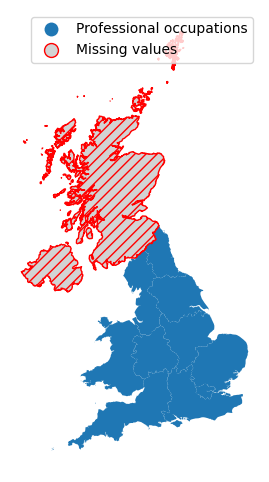

In [22]:
ax = map.plot(
    figsize=(10,6), 
    column="max_stat", 
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    },
    )

ax.set_axis_off()